# ModernBERT Model for Medical Dataset Name Extraction

This notebook trains and evaluates a **ModernBERT-large** token classification model for extracting dataset names from medical research articles.

**Architecture:** ModernBERT-large (answerdotai/ModernBERT-large) -> Dropout -> Linear(1024, 3) -> CrossEntropyLoss

**Key feature:** 8192-token context window (16x SciBERT/CRF's 512). Uses the same 542 labeled documents + 151 OOD documents as the CRF and SciBERT baselines, with the same seed (42). Chunk sizes are scaled up (6000 chars vs 1500) to exploit the longer context, so chunk counts will differ from the baselines — comparison is done at the document/entity level.

**Prerequisites:** Run `modernbert_data_preparation.ipynb` first to generate tokenized data in `modernbert_data/`.

| Section | Description |
|---------|-------------|
| 1 | Setup and configuration (GPU-aware precision) |
| 2 | Load prepared ModernBERT-tokenized data |
| 3 | PyTorch Dataset and DataLoader |
| 4 | ModernBERT token classification model architecture |
| 5 | Training loop (grad-accum + bf16/fp16 mixed precision) |
| 6 | Evaluation + 3-way comparison (CRF vs SciBERT vs ModernBERT) |
| 7 | Error analysis |
| 8 | Save model and push to HuggingFace |


## 1. Setup and Configuration

In [7]:
# Install dependencies
%pip install -q torch transformers>=4.48 seqeval joblib huggingface_hub pandas matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import os
import pickle
import warnings
import contextlib
from collections import Counter
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from transformers import __version__ as transformers_version
from packaging import version
from seqeval.metrics import (
    classification_report as seqeval_classification_report,
    f1_score as seqeval_f1,
)
from huggingface_hub import HfApi, login
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ModernBERT requires transformers>=4.48 for native support
assert version.parse(transformers_version) >= version.parse("4.48"), (
    f"transformers>=4.48 required for ModernBERT, got {transformers_version}"
)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = "./modernbert_data"
OUTPUT_DIR = "modernbert_MeDataset-NER-540-samples-OOD"
MODERNBERT_MODEL_NAME = "answerdotai/ModernBERT-large"
HF_REPO_ID = "haiderAI/modernbert-large-MeDataset-NER-540-samples-OOD"
HF_PRIVATE = True
SEED = 42

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# GPU-aware precision: bf16 on Blackwell/Ampere (RTX 5070 Ti), fp16+GradScaler on Turing/Volta (Titan RTX / Titan V)
if torch.cuda.is_available():
    USE_BF16 = torch.cuda.is_bf16_supported()
    USE_FP16 = not USE_BF16
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    USE_BF16 = False
    USE_FP16 = False
    GPU_NAME = "cpu"

# Reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Label mapping
label2id = {"O": 0, "B-Dataset": 1, "I-Dataset": 2}
id2label = {v: k for k, v in label2id.items()}
NUM_LABELS = len(label2id)

os.makedirs(OUTPUT_DIR, exist_ok=True)

PRECISION_STR = "bf16" if USE_BF16 else ("fp16 + GradScaler" if USE_FP16 else "fp32")
print(f"Device:             {DEVICE}  ({GPU_NAME})")
print(f"Precision:          {PRECISION_STR}")
print(f"ModernBERT model:   {MODERNBERT_MODEL_NAME}")
print(f"Max seq length:     8192")
print(f"Data directory:     {DATA_DIR}")
print(f"Output directory:   {OUTPUT_DIR}")
print(f"HuggingFace repo:   {HF_REPO_ID}")
print(f"transformers:       {transformers_version}")


Device:             cuda  (NVIDIA GeForce RTX 5070 Ti)
Precision:          bf16
ModernBERT model:   answerdotai/ModernBERT-large
Max seq length:     8192
Data directory:     ./modernbert_data
Output directory:   modernbert_MeDataset-NER-540-samples-OOD
HuggingFace repo:   haiderAI/modernbert-large-MeDataset-NER-540-samples-OOD
transformers:       5.5.4


## 2. Load Prepared Data

In [2]:
# Load ModernBERT-tokenized data for all splits
def load_pickle(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

train_data = load_pickle(os.path.join(DATA_DIR, "train.pkl"))
val_data = load_pickle(os.path.join(DATA_DIR, "val.pkl"))
test_data = load_pickle(os.path.join(DATA_DIR, "test.pkl"))
ood_data = load_pickle(os.path.join(DATA_DIR, "ood.pkl"))

# Load metadata
with open(os.path.join(DATA_DIR, "metadata.json"), 'r') as f:
    metadata = json.load(f)

print(f"{'Split':<8} {'Examples':>8} {'Mean Tokens':>12} {'Total Entities':>15}")
print("-" * 50)
for name, data in [("Train", train_data), ("Val", val_data),
                    ("Test", test_data), ("OOD", ood_data)]:
    lengths = [len(ex['input_ids']) for ex in data]
    n_entities = sum(len(ex['gold_entities']) for ex in data)
    print(f"{name:<8} {len(data):>8} {np.mean(lengths):>12.0f} {n_entities:>15}")


Split    Examples  Mean Tokens  Total Entities
--------------------------------------------------
Train        2324         1027            9236
Val           309         1014            1341
Test          466         1033            1951
OOD          1142         1030            5153


In [3]:
# Display 5 sample sequences from training data
tokenizer = AutoTokenizer.from_pretrained(MODERNBERT_MODEL_NAME)

print("=" * 70)
print("SAMPLE TRAINING SEQUENCES (ModernBERT tokenized)")
print("=" * 70)

sample_count = 0
for ex in train_data:
    if any(l in (1, 2) for l in ex['labels']):
        print(f"--- Sample {sample_count + 1} ---")
        tokens = tokenizer.convert_ids_to_tokens(ex['input_ids'])
        print(f"Gold entities: {ex['gold_entities']}")
        print(f"Truncated: {ex['was_truncated']}")
        print(f"{'Token':<25} {'Label':>6}")
        print("-" * 35)
        # Only print the first 120 tokens for readability at 8K context
        for tok, label in list(zip(tokens, ex['labels']))[:120]:
            if label == -100:
                tag_str = "  -"
            else:
                tag_str = id2label[label]
            marker = " <<" if label in (1, 2) else ""
            print(f"{tok:<25} {tag_str:>6}{marker}")
        if len(tokens) > 120:
            print(f"  ... ({len(tokens) - 120} more tokens truncated from display)")
        sample_count += 1
        if sample_count >= 5:
            break


config.json: 0.00B [00:00, ?B/s]

SAMPLE TRAINING SEQUENCES (ModernBERT tokenized)
--- Sample 1 ---
Gold entities: ['PCam dataset', 'PCam dataset', 'OASIS dataset']
Truncated: False
Token                      Label
-----------------------------------
[CLS]                          -
he                             O
ĠRot                           O
ation                          -
ĠEq                            O
.                              O
ĠCNN                           O
Ġ(                             O
0                              O
.                              O
963                            O
)                              O
Ġand                           O
ĠD                             O
ensen                          -
et                             -
Ġmodels                        O
Ġ(                             O
0                              O
.                              O
9                              O
62                             -
)                              O
Ġon                     

## 3. PyTorch Dataset and DataLoader

In [4]:
class NERDataset(Dataset):
    """PyTorch Dataset for ModernBERT NER sequences."""

    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            'input_ids': torch.tensor(ex['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(ex['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(ex['labels'], dtype=torch.long),
        }


def collate_fn(batch, pad_token_id=0):
    """Pad batch sequences to equal length."""
    max_len = max(len(item['input_ids']) for item in batch)

    input_ids = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.full((len(batch), max_len), -100, dtype=torch.long)

    for i, item in enumerate(batch):
        seq_len = len(item['input_ids'])
        input_ids[i, :seq_len] = item['input_ids']
        attention_mask[i, :seq_len] = item['attention_mask']
        labels[i, :seq_len] = item['labels']

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
    }


# Quick sanity check
train_dataset = NERDataset(train_data)
sample = train_dataset[0]
print(f"Dataset size: {len(train_dataset)}")
print(f"Sample keys: {list(sample.keys())}")
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample labels shape: {sample['labels'].shape}")

# Test collate_fn with a small batch
test_batch = [train_dataset[i] for i in range(3)]
collated = collate_fn(test_batch, tokenizer.pad_token_id)
print(f"Collated batch shapes:")
for k, v in collated.items():
    print(f"  {k}: {v.shape}")


Dataset size: 2324
Sample keys: ['input_ids', 'attention_mask', 'labels']
Sample input_ids shape: torch.Size([1304])
Sample labels shape: torch.Size([1304])
Collated batch shapes:
  input_ids: torch.Size([3, 1337])
  attention_mask: torch.Size([3, 1337])
  labels: torch.Size([3, 1337])


## 4. ModernBERT Token Classification Model Architecture


In [5]:
class ModernBERTTokenClassifier(nn.Module):
    """ModernBERT encoder with a linear classification head for sequence labeling.

    Architecture: ModernBERT-large -> Dropout -> Linear(1024, num_labels) -> CrossEntropyLoss
    Labels of -100 are ignored by CrossEntropyLoss (special tokens, non-first subwords).
    """

    def __init__(self, model_name, num_labels=3, dropout=0.1, freeze_layers=0,
                 use_gradient_checkpointing=True):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

        # ModernBERT-large at 8K context is memory-heavy — checkpoint recomputation
        # trades compute for activation memory.
        if use_gradient_checkpointing:
            self.encoder.gradient_checkpointing_enable()

        # Optionally freeze lower layers to reduce overfitting / VRAM pressure.
        # ModernBERT exposes layers as encoder.layers (flat), not encoder.encoder.layer.
        if freeze_layers > 0:
            if hasattr(self.encoder, 'embeddings'):
                for param in self.encoder.embeddings.parameters():
                    param.requires_grad = False
            layers_attr = (self.encoder.layers if hasattr(self.encoder, 'layers')
                           else self.encoder.encoder.layer)
            for i in range(min(freeze_layers, len(layers_attr))):
                for param in layers_attr[i].parameters():
                    param.requires_grad = False

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = self.dropout(outputs.last_hidden_state)
        logits = self.linear(sequence_output)  # (batch, seq_len, num_labels)

        if labels is not None:
            # Training: cross-entropy loss (ignores -100 positions)
            loss = self.loss_fn(logits.view(-1, self.num_labels), labels.view(-1))
            return loss
        else:
            # Inference: argmax predictions
            predictions = torch.argmax(logits, dim=-1)
            return predictions


In [6]:
# Model parameter summary
model = ModernBERTTokenClassifier(MODERNBERT_MODEL_NAME, num_labels=NUM_LABELS)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

layers_attr = (model.encoder.layers if hasattr(model.encoder, 'layers')
               else model.encoder.encoder.layer)

print(f"Total parameters:              {total_params:,}")
print(f"Trainable parameters:          {trainable_params:,}")
print(f"Hidden size:                   {model.encoder.config.hidden_size}")
print(f"Max position embeddings:       {model.encoder.config.max_position_embeddings}")
print(f"Num encoder layers:            {len(layers_attr)}")
print(f"Linear head:                   {model.linear.in_features} -> {model.linear.out_features}")

# Component breakdown
enc_params = sum(p.numel() for p in model.encoder.parameters())
head_params = sum(p.numel() for p in model.linear.parameters())
print(f"Parameter breakdown:")
print(f"  ModernBERT encoder: {enc_params:>14,} ({enc_params/total_params:.1%})")
print(f"  Linear head:        {head_params:>14,} ({head_params/total_params:.1%})")

del model  # free memory before training
torch.cuda.empty_cache() if torch.cuda.is_available() else None


model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:              394,784,771
Trainable parameters:          394,784,771
Hidden size:                   1024
Max position embeddings:       8192
Num encoder layers:            28
Linear head:                   1024 -> 3
Parameter breakdown:
  ModernBERT encoder:    394,781,696 (100.0%)
  Linear head:                 3,075 (0.0%)


## 5. Training Loop (grad-accum + bf16/fp16 mixed precision)


In [7]:
def make_autocast_ctx(use_bf16, use_fp16):
    """Return the appropriate autocast context for the current GPU.

    bf16: RTX 5070 Ti (Blackwell) and Ampere+ — no loss scaling needed.
    fp16: Titan RTX (Turing) / Titan V (Volta) — requires GradScaler during training.
    """
    if use_bf16:
        return torch.autocast(device_type='cuda', dtype=torch.bfloat16)
    if use_fp16:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return contextlib.nullcontext()


def train_one_epoch(model, dataloader, optimizer, scheduler, device, scaler=None,
                    max_grad_norm=1.0, accum_steps=1, use_bf16=False, use_fp16=False):
    """Train for one epoch with gradient accumulation + optional mixed precision.

    Returns average loss (measured in full-batch scale, i.e. un-scaled by accum_steps).
    """
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    pbar = tqdm(dataloader, desc="Training", leave=False)
    n_batches = 0

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device) for k, v in batch.items()}
        with make_autocast_ctx(use_bf16, use_fp16):
            loss = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels'],
            )
            loss = loss / accum_steps

        if use_fp16 and scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (step + 1) % accum_steps == 0:
            if use_fp16 and scaler is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item() * accum_steps:.4f}")

    return total_loss / max(n_batches, 1)


def evaluate_seqeval(model, dataloader, device, id2label_map,
                     use_bf16=False, use_fp16=False):
    """Run inference (with autocast) and return seqeval-compatible tag sequences + raw pred IDs."""
    model.eval()
    all_preds = []
    all_labels = []
    all_pred_ids = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            with make_autocast_ctx(use_bf16, use_fp16):
                predictions = model(
                    input_ids=batch['input_ids'],
                    attention_mask=batch['attention_mask'],
                )  # (batch, seq_len)

            labels_batch = batch['labels']

            for i in range(labels_batch.size(0)):
                # Only evaluate at positions where labels != -100
                # (first-subword content tokens)
                valid_mask = labels_batch[i] != -100
                true_labels_i = labels_batch[i][valid_mask].cpu().tolist()
                pred_labels_i = predictions[i][valid_mask].cpu().tolist()

                true_tags = [id2label_map[l] for l in true_labels_i]
                pred_tags = [id2label_map[l] for l in pred_labels_i]

                all_preds.append(pred_tags)
                all_labels.append(true_tags)
                all_pred_ids.append(pred_labels_i)

    return all_preds, all_labels, all_pred_ids


def run_training(model, train_loader, val_loader, optimizer, scheduler,
                 device, num_epochs, patience, max_grad_norm=1.0, save_path=None,
                 scaler=None, accum_steps=1, use_bf16=False, use_fp16=False):
    """Full training loop with early stopping. Returns training history."""
    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_f1': []}

    epoch_pbar = tqdm(range(num_epochs), desc="Epochs")
    for epoch in epoch_pbar:
        train_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler, device,
            scaler=scaler, max_grad_norm=max_grad_norm,
            accum_steps=accum_steps, use_bf16=use_bf16, use_fp16=use_fp16,
        )
        val_preds, val_labels, _ = evaluate_seqeval(
            model, val_loader, device, id2label,
            use_bf16=use_bf16, use_fp16=use_fp16,
        )
        val_f1 = seqeval_f1(val_labels, val_preds)

        history['train_loss'].append(train_loss)
        history['val_f1'].append(val_f1)

        epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", val_f1=f"{val_f1:.4f}")
        print(f"Epoch {epoch+1}/{num_epochs}: loss={train_loss:.4f}, val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            if save_path:
                torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Best validation F1: {best_val_f1:.4f}")
    return history, best_val_f1


In [8]:
# Default hyperparameters for ModernBERT-large training
# - Encoder LR 5e-5 follows the ModernBERT paper recommendation
# - Physical batch 1 + grad_accum 4 -> effective batch 4 (memory-safe at 8K context)
# - Gradient checkpointing is enabled inside the model (__init__ default)
ENCODER_LR = 5e-5
HEAD_LR = 1e-3
DROPOUT = 0.1
BATCH_SIZE = 1             # physical batch
GRAD_ACCUM_STEPS = 4       # effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 10
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
FREEZE_LAYERS = 0
PATIENCE = 3

# Create model (gradient checkpointing + autocast-ready)
model = ModernBERTTokenClassifier(
    MODERNBERT_MODEL_NAME, NUM_LABELS, DROPOUT, FREEZE_LAYERS,
    use_gradient_checkpointing=True,
).to(DEVICE)

# DataLoaders
train_loader = DataLoader(
    NERDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)
val_loader = DataLoader(
    NERDataset(val_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)

# Optimizer with differential learning rates
encoder_params = list(model.encoder.parameters())
head_params = list(model.linear.parameters())
optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': ENCODER_LR, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params,    'lr': HEAD_LR,    'weight_decay': 0.0},
])

# Scheduler counts optimizer steps, not forward passes. Each step takes
# GRAD_ACCUM_STEPS forward passes, so divide.
total_steps = (len(train_loader) * NUM_EPOCHS) // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# GradScaler only for fp16. bf16 and fp32 do not need it.
scaler = torch.amp.GradScaler("cuda") if USE_FP16 else None

save_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
print(f"Training ModernBERT-large with default hyperparameters...")
print(f"  Encoder LR: {ENCODER_LR}, Head LR: {HEAD_LR}")
print(f"  Physical batch: {BATCH_SIZE}, grad-accum: {GRAD_ACCUM_STEPS} (effective {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"  Epochs: {NUM_EPOCHS}, warmup: {warmup_steps}/{total_steps} opt steps")
print(f"  Precision: {PRECISION_STR}")
print(f"  Gradient checkpointing: enabled")
print()

history, best_f1 = run_training(
    model, train_loader, val_loader, optimizer, scheduler,
    DEVICE, NUM_EPOCHS, PATIENCE, MAX_GRAD_NORM, save_path,
    scaler=scaler, accum_steps=GRAD_ACCUM_STEPS,
    use_bf16=USE_BF16, use_fp16=USE_FP16,
)


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-large
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training ModernBERT-large with default hyperparameters...
  Encoder LR: 5e-05, Head LR: 0.001
  Physical batch: 1, grad-accum: 4 (effective 4)
  Epochs: 10, warmup: 581/5810 opt steps
  Precision: bf16
  Gradient checkpointing: enabled



Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/2324 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/309 [00:00<?, ?it/s]

Epoch 9/10: loss=0.0002, val_f1=0.8935


Training:   0%|          | 0/2324 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/309 [00:00<?, ?it/s]

Epoch 10/10: loss=0.0001, val_f1=0.9025
Best validation F1: 0.9025


Evaluating:   0%|          | 0/309 [00:00<?, ?it/s]

Validation set - seqeval classification report:
              precision    recall  f1-score   support

     Dataset       0.87      0.94      0.90      1325

   micro avg       0.87      0.94      0.90      1325
   macro avg       0.87      0.94      0.90      1325
weighted avg       0.87      0.94      0.90      1325



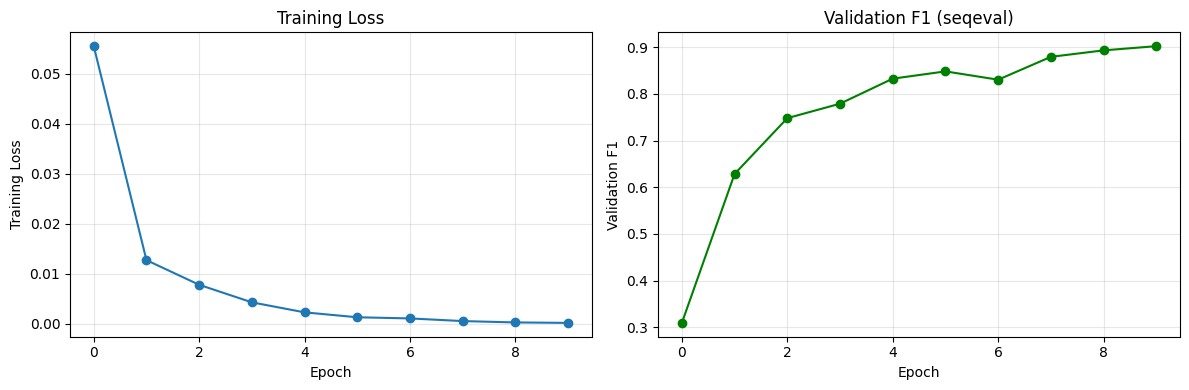


Training complete. Best val F1: 0.9025


In [9]:
# Load best model and print detailed validation report
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pt'), map_location=DEVICE))
val_preds, val_labels, _ = evaluate_seqeval(
    model, val_loader, DEVICE, id2label,
    use_bf16=USE_BF16, use_fp16=USE_FP16,
)

print("Validation set - seqeval classification report:")
print(seqeval_classification_report(val_labels, val_preds))

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_f1'], marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation F1')
ax2.set_title('Validation F1 (seqeval)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'initial_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining complete. Best val F1: {best_f1:.4f}")


## 6. Evaluation on Test and OOD Sets

Applies the same chunk-level exact/partial match methodology as the CRF and SciBERT baselines, plus a 3-way comparison table using their saved `eval_metrics.json`.


In [10]:
# seqeval classification report on test set
test_loader = DataLoader(
    NERDataset(test_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id))

test_preds, test_labels, test_pred_ids = evaluate_seqeval(
    model, test_loader, DEVICE, id2label,
    use_bf16=USE_BF16, use_fp16=USE_FP16,
)
test_f1_seqeval = seqeval_f1(test_labels, test_preds)

print("=" * 60)
print("TEST SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(test_labels, test_preds))
print(f"Entity-level F1 (seqeval): {test_f1_seqeval:.4f}")


Evaluating:   0%|          | 0/466 [00:00<?, ?it/s]

TEST SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.89      0.94      0.91      1949

   micro avg       0.89      0.94      0.91      1949
   macro avg       0.89      0.94      0.91      1949
weighted avg       0.89      0.94      0.91      1949

Entity-level F1 (seqeval): 0.9124


In [11]:
def modernbert_bio_to_entity_strings(example, pred_tags, tokenizer_obj, id2label_map):
    """Decode predictions back to entity strings using word grouping.

    Args:
        example: dict from data prep (has input_ids, word_ids, offset_mapping, text)
        pred_tags: list of predicted label ids for first-subword positions (labels != -100)
        tokenizer_obj: ModernBERT tokenizer (unused but kept for API consistency)
        id2label_map: {0: 'O', 1: 'B-Dataset', 2: 'I-Dataset'}

    Returns:
        List of predicted entity strings
    """
    input_ids = example['input_ids']
    word_ids_raw = example['word_ids']
    offset_mapping = example['offset_mapping']
    text = example['text']

    # Identify first-subword positions (same positions as labels != -100)
    seen_words = set()
    first_subword_positions = []
    for pos in range(len(input_ids)):
        wid = word_ids_raw[pos]
        if wid is not None and wid not in seen_words:
            seen_words.add(wid)
            first_subword_positions.append(pos)

    # Map predictions to word-level tags
    word_tags = {}  # word_id -> tag string
    for tag_idx, pos in enumerate(first_subword_positions):
        if tag_idx < len(pred_tags):
            wid = word_ids_raw[pos]
            word_tags[wid] = id2label_map[pred_tags[tag_idx]]

    # Get word character spans from offset_mapping
    word_spans = {}  # word_id -> (char_start, char_end)
    for pos in range(len(input_ids)):
        wid = word_ids_raw[pos]
        if wid is not None:
            tok_start, tok_end = offset_mapping[pos]
            if tok_end == 0:
                continue
            if wid not in word_spans:
                word_spans[wid] = (tok_start, tok_end)
            else:
                word_spans[wid] = (word_spans[wid][0], max(word_spans[wid][1], tok_end))

    # Decode entities using BIO tags on words
    entities = []
    current_start = None
    current_end = None

    for wid in sorted(word_spans.keys()):
        tag = word_tags.get(wid, 'O')
        ws, we = word_spans[wid]

        if tag.startswith('B-'):
            if current_start is not None:
                entities.append(text[current_start:current_end])
            current_start = ws
            current_end = we
        elif tag.startswith('I-') and current_start is not None:
            current_end = we
        else:
            if current_start is not None:
                entities.append(text[current_start:current_end])
                current_start = None
                current_end = None

    if current_start is not None:
        entities.append(text[current_start:current_end])

    return entities


def evaluate_chunk_level(data_examples, all_pred_tag_ids, tokenizer_obj, id2label_map):
    """Chunk-level exact & partial match evaluation."""
    tp = fp = fn = 0
    partial_tp = 0

    for ex, pred_tags in zip(data_examples, all_pred_tag_ids):
        pred_entities = modernbert_bio_to_entity_strings(ex, pred_tags, tokenizer_obj, id2label_map)
        gold_entities = ex['gold_entities']

        true_set = set(e.strip().lower() for e in gold_entities)
        pred_set = set(e.strip().lower() for e in pred_entities)

        # Exact match
        tp += len(true_set & pred_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        # Partial match
        for pmention in pred_set:
            if pmention not in true_set:
                for tmention in true_set:
                    if pmention in tmention or tmention in pmention:
                        partial_tp += 1
                        break

    # Compute metrics
    exact_p = tp / (tp + fp) if (tp + fp) > 0 else 0
    exact_r = tp / (tp + fn) if (tp + fn) > 0 else 0
    exact_f1 = 2 * exact_p * exact_r / (exact_p + exact_r) if (exact_p + exact_r) > 0 else 0

    adj_tp = tp + partial_tp
    partial_p = adj_tp / (adj_tp + fp - partial_tp) if (adj_tp + fp - partial_tp) > 0 else 0
    partial_r = adj_tp / (adj_tp + fn - partial_tp) if (adj_tp + fn - partial_tp) > 0 else 0
    partial_f1 = 2 * partial_p * partial_r / (partial_p + partial_r) if (partial_p + partial_r) > 0 else 0

    return {
        "exact_match": {"precision": exact_p, "recall": exact_r, "f1": exact_f1,
                        "tp": tp, "fp": fp, "fn": fn},
        "partial_match": {"precision": partial_p, "recall": partial_r, "f1": partial_f1,
                          "partial_tp": partial_tp},
    }


In [12]:
# Chunk-level evaluation on test and validation sets
test_metrics = evaluate_chunk_level(test_data, test_pred_ids, tokenizer, id2label)

# Also get val predictions for comparison
val_preds_final, val_labels_final, val_pred_ids = evaluate_seqeval(
    model, val_loader, DEVICE, id2label,
    use_bf16=USE_BF16, use_fp16=USE_FP16,
)
val_metrics = evaluate_chunk_level(val_data, val_pred_ids, tokenizer, id2label)

print("=" * 60)
print("CHUNK-LEVEL EVALUATION (matching CRF/SciBERT baseline methodology)")
print("=" * 60)

print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10}")
print("-" * 45)
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f}")
print(f"\n{'Counts':<20} {'Val':>10} {'Test (ID)':>10}")
print("-" * 45)
print(f"{'TP':<20} {val_metrics['exact_match']['tp']:>10} {test_metrics['exact_match']['tp']:>10}")
print(f"{'FP':<20} {val_metrics['exact_match']['fp']:>10} {test_metrics['exact_match']['fp']:>10}")
print(f"{'FN':<20} {val_metrics['exact_match']['fn']:>10} {test_metrics['exact_match']['fn']:>10}")
print(f"{'Partial TP':<20} {val_metrics['partial_match']['partial_tp']:>10} {test_metrics['partial_match']['partial_tp']:>10}")


Evaluating:   0%|          | 0/309 [00:00<?, ?it/s]

CHUNK-LEVEL EVALUATION (matching CRF/SciBERT baseline methodology)

Metric                      Val  Test (ID)
---------------------------------------------
Exact P                  0.8689     0.8815
Exact R                  0.9149     0.9222
Exact F1                 0.8913     0.9014
Partial P                0.9379     0.9551
Partial R                0.9877     0.9992
Partial F1               0.9622     0.9766

Counts                      Val  Test (ID)
---------------------------------------------
TP                          742       1138
FP                          112        153
FN                           69         96
Partial TP                   59         95


### Out-of-Distribution (OOD) Evaluation

The OOD set tests generalization to entirely new documents not seen during training.
Same processing pipeline (negative sampling + entity-centered augmentation, 6000-char primary chunks, 4000-char augmentation windows) applied for consistency with val/test splits.


In [13]:
# seqeval classification report on OOD set
ood_loader = DataLoader(
    NERDataset(ood_data), batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)

ood_preds, ood_labels, ood_pred_ids = evaluate_seqeval(
    model, ood_loader, DEVICE, id2label,
    use_bf16=USE_BF16, use_fp16=USE_FP16,
)
ood_f1_seqeval = seqeval_f1(ood_labels, ood_preds)

print("=" * 60)
print("OOD SET - seqeval Classification Report")
print("=" * 60)
print(seqeval_classification_report(ood_labels, ood_preds))
print(f"Entity-level F1 (seqeval): {ood_f1_seqeval:.4f}")


Evaluating:   0%|          | 0/1142 [00:00<?, ?it/s]

OOD SET - seqeval Classification Report
              precision    recall  f1-score   support

     Dataset       0.65      0.68      0.67      5150

   micro avg       0.65      0.68      0.67      5150
   macro avg       0.65      0.68      0.67      5150
weighted avg       0.65      0.68      0.67      5150

Entity-level F1 (seqeval): 0.6673


In [14]:
# Chunk-level evaluation on OOD set + 3-way comparison (CRF vs SciBERT vs ModernBERT)
ood_metrics = evaluate_chunk_level(ood_data, ood_pred_ids, tokenizer, id2label)

print("=" * 60)
print("COMPARISON: Val vs Test (ID) vs OOD — ModernBERT only")
print("=" * 60)

val_f1_seqeval_final = seqeval_f1(val_labels_final, val_preds_final)
print(f"\n{'Metric':<20} {'Val':>10} {'Test (ID)':>10} {'OOD':>10}")
print("-" * 55)
print(f"{'seqeval F1':<20} {val_f1_seqeval_final:>10.4f} {test_f1_seqeval:>10.4f} {ood_f1_seqeval:>10.4f}")
print(f"{'Exact P':<20} {val_metrics['exact_match']['precision']:>10.4f} {test_metrics['exact_match']['precision']:>10.4f} {ood_metrics['exact_match']['precision']:>10.4f}")
print(f"{'Exact R':<20} {val_metrics['exact_match']['recall']:>10.4f} {test_metrics['exact_match']['recall']:>10.4f} {ood_metrics['exact_match']['recall']:>10.4f}")
print(f"{'Exact F1':<20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f} {ood_metrics['exact_match']['f1']:>10.4f}")
print(f"{'Partial P':<20} {val_metrics['partial_match']['precision']:>10.4f} {test_metrics['partial_match']['precision']:>10.4f} {ood_metrics['partial_match']['precision']:>10.4f}")
print(f"{'Partial R':<20} {val_metrics['partial_match']['recall']:>10.4f} {test_metrics['partial_match']['recall']:>10.4f} {ood_metrics['partial_match']['recall']:>10.4f}")
print(f"{'Partial F1':<20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f} {ood_metrics['partial_match']['f1']:>10.4f}")

# -----------------------------------------------------------------
# 3-way comparison: CRF vs SciBERT vs ModernBERT (same 542 + 151 docs, same seed)
# -----------------------------------------------------------------
own_metrics = {
    'val':  {'seqeval_f1': val_f1_seqeval_final,
             'exact_match': val_metrics['exact_match'],
             'partial_match': val_metrics['partial_match']},
    'test': {'seqeval_f1': test_f1_seqeval,
             'exact_match': test_metrics['exact_match'],
             'partial_match': test_metrics['partial_match']},
    'ood':  {'seqeval_f1': ood_f1_seqeval,
             'exact_match': ood_metrics['exact_match'],
             'partial_match': ood_metrics['partial_match']},
}

comparisons = []
for name, path in [
    ("CRF",     "../CRF/crf_medical_ner/eval_metrics.json"),
    ("SciBERT", "../SciBERT/scibert_MeDataset-NER-540-samples-OOD/eval_metrics.json"),
]:
    if os.path.exists(path):
        with open(path, 'r') as f:
            comparisons.append((name, json.load(f)))
    else:
        print(f"[warn] {name} baseline not found at {path} — skipping in comparison")

comparisons.append(("ModernBERT", own_metrics))

print("\n" + "=" * 70)
print("3-WAY COMPARISON: CRF vs SciBERT vs ModernBERT")
print("(same 542 labeled docs + 151 OOD docs, same seed=42)")
print("=" * 70)
print(f"\n{'Model':<12} {'Split':<6} {'seqeval F1':>11} {'Exact F1':>10} {'Partial F1':>11}")
print("-" * 55)
for name, m in comparisons:
    for split in ['val', 'test', 'ood']:
        if split in m:
            s = m[split]
            seq_f1 = s.get('seqeval_f1', 0) or 0
            em_f1 = s.get('exact_match', {}).get('f1', 0) if isinstance(s.get('exact_match'), dict) else 0
            pm_f1 = s.get('partial_match', {}).get('f1', 0) if isinstance(s.get('partial_match'), dict) else 0
            print(f"{name:<12} {split.upper():<6} {seq_f1:>11.4f} {em_f1:>10.4f} {pm_f1:>11.4f}")
    print("-" * 55)

print("\nNote: All three models trained on the same 542 labeled documents (seed=42) and")
print("evaluated on the same 151-doc OOD set. All pipelines use negative sampling (0.15)")
print("+ entity-centered augmentation. ModernBERT uses 6000-char primary chunks +")
print("4000-char augmentation windows to exploit its 8K context, so chunk counts differ.")


COMPARISON: Val vs Test (ID) vs OOD — ModernBERT only

Metric                      Val  Test (ID)        OOD
-------------------------------------------------------
seqeval F1               0.9025     0.9124     0.6673
Exact P                  0.8689     0.8815     0.6584
Exact R                  0.9149     0.9222     0.7204
Exact F1                 0.8913     0.9014     0.6880
Partial P                0.9379     0.9551     0.8290
Partial R                0.9877     0.9992     0.9071
Partial F1               0.9622     0.9766     0.8663
[warn] CRF baseline not found at ../CRF/crf_medical_ner/eval_metrics.json — skipping in comparison
[warn] SciBERT baseline not found at ../SciBERT/scibert_MeDataset-NER-540-samples-OOD/eval_metrics.json — skipping in comparison

3-WAY COMPARISON: CRF vs SciBERT vs ModernBERT
(same 542 labeled docs + 151 OOD docs, same seed=42)

Model        Split   seqeval F1   Exact F1  Partial F1
-------------------------------------------------------
ModernBERT   VAL

## 7. Error Analysis

In [15]:
# Collect concrete examples of TP, FP, FN, and partial matches
def collect_error_examples(data_examples, all_pred_tag_ids, tokenizer_obj, id2label_map):
    """Collect per-chunk TP, FP, FN, and partial match examples."""
    tp_examples = []
    fp_examples = []
    fn_examples = []
    partial_examples = []

    for ex, pred_tags in zip(data_examples, all_pred_tag_ids):
        pred_entities = modernbert_bio_to_entity_strings(ex, pred_tags, tokenizer_obj, id2label_map)
        gold_entities = ex['gold_entities']

        true_set = set(e.strip().lower() for e in gold_entities)
        pred_set = set(e.strip().lower() for e in pred_entities)

        for e in true_set & pred_set:
            tp_examples.append(e)
        for e in pred_set - true_set:
            fp_examples.append(e)
        for e in true_set - pred_set:
            fn_examples.append(e)
        for pmention in pred_set:
            if pmention not in true_set:
                for tmention in true_set:
                    if pmention in tmention or tmention in pmention:
                        partial_examples.append((pmention, tmention))
                        break

    return tp_examples, fp_examples, fn_examples, partial_examples

tp_examples, fp_examples, fn_examples, partial_examples = collect_error_examples(
    test_data, test_pred_ids, tokenizer, id2label
)

print("=" * 60)
print("TEST SET ERROR EXAMPLES")
print("=" * 60)

print(f"\nTP: {len(tp_examples)}, FP: {len(fp_examples)}, FN: {len(fn_examples)}, Partial: {len(partial_examples)}")

print(f"\n--- True Positives (showing 5 of {len(tp_examples)}) ---")
for e in tp_examples[:5]:
    print(f"  {e}")

print(f"\n--- False Positives (showing 5 of {len(fp_examples)}) ---")
for e in fp_examples[:5]:
    print(f"  {e}")

print(f"\n--- False Negatives (showing 5 of {len(fn_examples)}) ---")
for e in fn_examples[:5]:
    print(f"  {e}")

print(f"\n--- Partial Matches (showing 5 of {len(partial_examples)}) ---")
for pred, gold in partial_examples[:5]:
    print(f"  Predicted: '{pred}' | Gold: '{gold}'")


TEST SET ERROR EXAMPLES

TP: 1138, FP: 153, FN: 96, Partial: 95

--- True Positives (showing 5 of 1138) ---
  prostatex challenge
  prostatex dataset
  biocyc database version 13.0
  dbtbs database
  radiopaedia

--- False Positives (showing 5 of 153) ---
  promise12
  human connectom project (hcp)
  indiana university chest x-ray collection (iu x-ray
  alzheimer's disease neuro imaging initiative (adni).
  bc2.

--- False Negatives (showing 5 of 96) ---
  ct pancreas
  promise12 challenge
  fetal dataset
  indiana university chest x-ray collection (iu x-ray)
  pet scan image datasets

--- Partial Matches (showing 5 of 95) ---
  Predicted: 'promise12' | Gold: 'promise12 challenge'
  Predicted: 'indiana university chest x-ray collection (iu x-ray' | Gold: 'iu x-ray'
  Predicted: 'bc2.' | Gold: 'bc2.5 training'
  Predicted: 'biocreative' | Gold: 'biocreative 2.5 test data set (v )'
  Predicted: 'information extraction from images (ixi' | Gold: 'information extraction from images (ixi) da

In [16]:
# Error pattern analysis
print("=" * 60)
print("ERROR PATTERNS")
print("=" * 60)

# FP/FN by entity word count
fp_word_counts = Counter(len(e.split()) for e in fp_examples)
fn_word_counts = Counter(len(e.split()) for e in fn_examples)
tp_word_counts = Counter(len(e.split()) for e in tp_examples)

print("\nEntity length distribution (word count):")
all_lengths = sorted(set(list(fp_word_counts.keys()) + list(fn_word_counts.keys()) + list(tp_word_counts.keys())))
print(f"{'Length':<10} {'TP':>6} {'FP':>6} {'FN':>6}")
print("-" * 35)
for length in all_lengths[:10]:
    print(f"{length:<10} {tp_word_counts.get(length, 0):>6} {fp_word_counts.get(length, 0):>6} {fn_word_counts.get(length, 0):>6}")

# Top 10 most common FP and FN
print(f"\n--- Top 10 Most Common False Positives ---")
for e, count in Counter(fp_examples).most_common(10):
    print(f"  [{count}x] {e}")

print(f"\n--- Top 10 Most Common False Negatives ---")
for e, count in Counter(fn_examples).most_common(10):
    print(f"  [{count}x] {e}")

ERROR PATTERNS

Entity length distribution (word count):
Length         TP     FP     FN
-----------------------------------
1             422     57     26
2             432     41     31
3             127     19     11
4              67     15     10
5              46     12      8
6              12      4      3
7              20      2      3
8               8      3      4
9               3      0      0
23              1      0      0

--- Top 10 Most Common False Positives ---
  [2x] promise12
  [2x] human connectom project (hcp)
  [2x] aptos 2019
  [2x] brats
  [2x] tn-scui dataset
  [2x] tn-scui 2020 challenge
  [2x] ct seg1 dataset
  [2x] brats21
  [2x] msd(pancreas),
  [2x] thomson reuters

--- Top 10 Most Common False Negatives ---
  [3x] chembl
  [2x] fetal dataset
  [2x] pet scan image datasets
  [2x] eth-ucy
  [2x] sdd
  [2x] aptos 2019 blindness detection
  [2x] brats 2020 validation dataset
  [2x] tn-scui 2020
  [2x] brats21 challenge
  [2x] msd(pancreas)


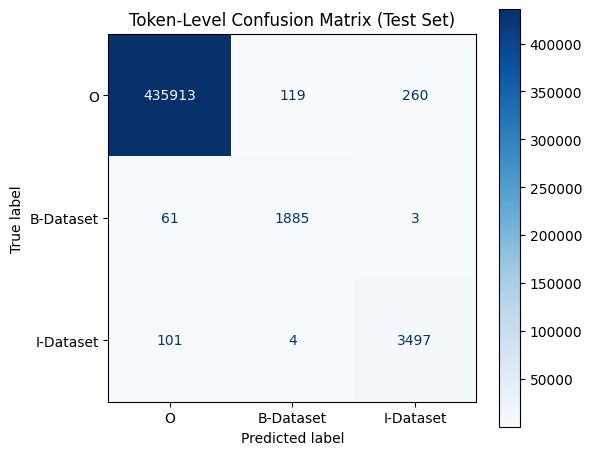

Per-class accuracy:
  O: 435913/436292 (99.9%)
  B-Dataset: 1885/1949 (96.7%)
  I-Dataset: 3497/3602 (97.1%)


In [17]:
# Token-level confusion matrix visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten all test predictions and true labels
all_true_flat = [l for seq in test_labels for l in seq]
all_pred_flat = [p for seq in test_preds for p in seq]

labels_list = ['O', 'B-Dataset', 'I-Dataset']
cm = confusion_matrix(all_true_flat, all_pred_flat, labels=labels_list)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_list)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Token-Level Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print per-class accuracy
print("Per-class accuracy:")
for i, label in enumerate(labels_list):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"  {label}: {correct}/{total} ({acc:.1%})")

In [18]:
# OOD-specific error analysis
print("=" * 60)
print("OOD ERROR ANALYSIS")
print("=" * 60)

ood_tp, ood_fp, ood_fn, ood_partial = collect_error_examples(
    ood_data, ood_pred_ids, tokenizer, id2label
)

print(f"\nOOD TP: {len(ood_tp)}, FP: {len(ood_fp)}, FN: {len(ood_fn)}, Partial: {len(ood_partial)}")

print(f"\n--- OOD False Positives (showing 5 of {len(ood_fp)}) ---")
for e in ood_fp[:5]:
    print(f"  {e}")

print(f"\n--- OOD False Negatives (showing 5 of {len(ood_fn)}) ---")
for e in ood_fn[:5]:
    print(f"  {e}")

print(f"\n--- OOD Partial Matches (showing 5 of {len(ood_partial)}) ---")
for pred, gold in ood_partial[:5]:
    print(f"  Predicted: '{pred}' | Gold: '{gold}'")

# Compare error rates: ID vs OOD
id_error_rate = (len(fp_examples) + len(fn_examples)) / max(len(tp_examples) + len(fp_examples) + len(fn_examples), 1)
ood_error_rate = (len(ood_fp) + len(ood_fn)) / max(len(ood_tp) + len(ood_fp) + len(ood_fn), 1)
print(f"\nError rate comparison:")
print(f"  Test (ID): {id_error_rate:.3f}")
print(f"  OOD:       {ood_error_rate:.3f}")

# Top OOD FN
print(f"\n--- Top 10 Most Common OOD False Negatives ---")
for e, count in Counter(ood_fn).most_common(10):
    print(f"  [{count}x] {e}")

OOD ERROR ANALYSIS

OOD TP: 2087, FP: 1083, FN: 810, Partial: 541

--- OOD False Positives (showing 5 of 1083) ---
  kodak
  drive (digital retinal images for vessel extraction),
  isprs
  usc-sipi
  bcss dataset

--- OOD False Negatives (showing 5 of 810) ---
  usc-sipi sequences
  isprs potsdam
  drive
  digital retinal images for vessel extraction
  bcss dataset’s

--- OOD Partial Matches (showing 5 of 541) ---
  Predicted: 'usc-sipi' | Gold: 'usc-sipi sequences'
  Predicted: 'drive (digital retinal images for vessel extraction),' | Gold: 'drive'
  Predicted: 'isprs' | Gold: 'isprs potsdam'
  Predicted: 'bcss dataset' | Gold: 'bcss dataset’s'
  Predicted: 'oct dataset' | Gold: 'kidney oct dataset'

Error rate comparison:
  Test (ID): 0.180
  OOD:       0.476

--- Top 10 Most Common OOD False Negatives ---
  [23x] busi
  [13x] tcga
  [10x] kidney oct dataset
  [9x] bach
  [8x] padchest
  [8x] idc
  [8x] invasive ductal carcinoma
  [7x] her2
  [7x] echo-net
  [6x] university of waterl

## 8. Save Model and Push to HuggingFace

In [19]:
# best_model.pt was already saved during training (Section 5)
print(f"Model checkpoint: {os.path.join(OUTPUT_DIR, 'best_model.pt')}")
print(f"  Size: {os.path.getsize(os.path.join(OUTPUT_DIR, 'best_model.pt'))/1024/1024:.1f} MB")

# Save config.json
config = {
    "model_type": "modernbert-token-classifier",
    "base_model": MODERNBERT_MODEL_NAME,
    "num_labels": NUM_LABELS,
    "hidden_size": 1024,
    "max_seq_length": metadata.get("max_seq_length", 8192),
    "entity_types": ["Dataset"],
    "entity_description": "Names of datasets, corpus, collections, databases, benchmarks used in scientific research",
    "bio_labels": ["O", "B-Dataset", "I-Dataset"],
    "label2id": label2id,
    "hyperparameters": {
        "encoder_lr": ENCODER_LR,
        "head_lr": HEAD_LR,
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM_STEPS,
        "num_epochs": NUM_EPOCHS,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "freeze_layers": FREEZE_LAYERS,
        "precision": PRECISION_STR,
        "gpu": GPU_NAME,
    },
    "training_data": {
        "source": metadata.get("source_file", "data-annotations.json"),
        "ood_source": metadata.get("ood_source_file", "151-eval.json"),
        "total_documents": metadata.get("total_documents", "unknown"),
        "ood_documents": metadata.get("ood_documents", "unknown"),
        "train_examples": len(train_data),
        "val_examples": len(val_data),
        "test_examples": len(test_data),
        "ood_examples": len(ood_data),
        "chunk_size_chars": metadata.get("chunk_size", 6000),
        "chunk_overlap_chars": metadata.get("chunk_overlap", 500),
        "negative_sampling": metadata.get("negative_sampling", True),
        "negative_sample_ratio": metadata.get("negative_sample_ratio", 0.15),
        "augmentation": metadata.get("augmentation", True),
        "augmentation_window_size": metadata.get("augmentation_window_size", 4000),
        "augmentation_max_per_doc": metadata.get("augmentation_max_per_doc", 3),
    },
}

with open(os.path.join(OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print(f"Saved config.json")

# Save eval_metrics.json
val_f1_final = seqeval_f1(val_labels_final, val_preds_final)
eval_metrics = {
    "val": {
        "seqeval_f1": val_f1_final,
        "exact_match": val_metrics["exact_match"],
        "partial_match": val_metrics["partial_match"],
    },
    "test": {
        "seqeval_f1": test_f1_seqeval,
        "exact_match": test_metrics["exact_match"],
        "partial_match": test_metrics["partial_match"],
    },
    "ood": {
        "seqeval_f1": ood_f1_seqeval,
        "exact_match": ood_metrics["exact_match"],
        "partial_match": ood_metrics["partial_match"],
    },
}

with open(os.path.join(OUTPUT_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=2)
print(f"Saved eval_metrics.json")


Model checkpoint: modernbert_MeDataset-NER-540-samples-OOD/best_model.pt
  Size: 1506.1 MB
Saved config.json
Saved eval_metrics.json


In [20]:
%%writefile ./modernbert_MeDataset-NER-540-samples-OOD/inference.py
"""Standalone inference script for ModernBERT-large Medical Dataset NER model.

Chunks long inputs at 6000 chars (matching training) and merges per-chunk entities.
"""
import json
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer


class ModernBERTTokenClassifier(nn.Module):
    def __init__(self, model_name, num_labels=3, dropout=0.1, freeze_layers=0,
                 use_gradient_checkpointing=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(self.encoder.config.hidden_size, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq_out = self.dropout(outputs.last_hidden_state)
        logits = self.linear(seq_out)
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fn(logits.view(-1, self.num_labels), labels.view(-1))
            return loss
        return torch.argmax(logits, dim=-1)


def load_model(model_dir, device="cpu"):
    with open(f"{model_dir}/config.json", "r") as f:
        config = json.load(f)

    model = ModernBERTTokenClassifier(
        config["base_model"],
        config["num_labels"],
        config["hyperparameters"].get("dropout", 0.1),
        config["hyperparameters"].get("freeze_layers", 0),
    )
    model.load_state_dict(
        torch.load(f"{model_dir}/best_model.pt", map_location=device)
    )
    model.to(device).eval()

    tokenizer = AutoTokenizer.from_pretrained(config["base_model"])
    id2label = {int(v): k for k, v in config["label2id"].items()}
    return model, tokenizer, id2label, config


def _predict_chunk(text, offset_base, model, tokenizer, id2label, device,
                   max_length=8192):
    enc = tokenizer(
        text, return_offsets_mapping=True, add_special_tokens=True,
        truncation=True, max_length=max_length,
        return_attention_mask=True, return_tensors="pt"
    )
    ids = enc["input_ids"].to(device)
    attn = enc["attention_mask"].to(device)
    offsets = enc["offset_mapping"][0].tolist()
    wids = enc.word_ids(0)

    with torch.no_grad():
        preds = model(input_ids=ids, attention_mask=attn)[0].cpu().tolist()

    word_tags = {}
    seen = set()
    for i, wid in enumerate(wids):
        if wid is not None and wid not in seen:
            seen.add(wid)
            word_tags[wid] = id2label[preds[i]]

    word_spans = {}
    for i, wid in enumerate(wids):
        if wid is not None:
            s, e = offsets[i]
            if e == 0: continue
            word_spans[wid] = (s, max(word_spans.get(wid, (s, 0))[1], e))

    entities, curr_s, curr_e = [], None, None
    for wid in sorted(word_spans.keys()):
        tag = word_tags.get(wid, "O")
        s, e = word_spans[wid]
        if tag.startswith("B-"):
            if curr_s is not None:
                entities.append({
                    "text": text[curr_s:curr_e],
                    "start": curr_s + offset_base,
                    "end": curr_e + offset_base,
                    "label": "Dataset",
                })
            curr_s, curr_e = s, e
        elif tag.startswith("I-") and curr_s is not None:
            curr_e = e
        else:
            if curr_s is not None:
                entities.append({
                    "text": text[curr_s:curr_e],
                    "start": curr_s + offset_base,
                    "end": curr_e + offset_base,
                    "label": "Dataset",
                })
                curr_s, curr_e = None, None
    if curr_s is not None:
        entities.append({
            "text": text[curr_s:curr_e],
            "start": curr_s + offset_base,
            "end": curr_e + offset_base,
            "label": "Dataset",
        })
    return entities


def predict(text, model, tokenizer, id2label, device="cpu",
            chunk_size=6000, chunk_overlap=500, max_length=8192):
    """Predict entities on arbitrarily long text by chunking at the character level."""
    if len(text) <= chunk_size:
        return _predict_chunk(text, 0, model, tokenizer, id2label, device, max_length)

    results = []
    seen_spans = set()
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end]
        for ent in _predict_chunk(chunk, start, model, tokenizer, id2label, device, max_length):
            key = (ent["start"], ent["end"], ent["text"])
            if key not in seen_spans:
                seen_spans.add(key)
                results.append(ent)
        if end == len(text):
            break
        start = end - chunk_overlap
    return results


if __name__ == "__main__":
    import sys
    d = sys.argv[1] if len(sys.argv) > 1 else "."
    model, tok, id2l, cfg = load_model(d)
    print("Loaded ModernBERT model from {}".format(d))
    print("  Model: {}".format(cfg["base_model"]))
    print("  Max seq length: {}".format(cfg.get("max_seq_length", 8192)))
    print("  Labels: {}".format(cfg.get("bio_labels", list(id2l.values()))))

    txt = "We evaluated our method on the MIMIC-III dataset."
    print("\nSample text: {}".format(txt))
    ents = predict(txt, model, tok, id2l)
    print("Entities found: {}".format(len(ents)))
    for ent in ents:
        print("  [{}:{}] {} ({})".format(
            ent["start"], ent["end"], ent["text"], ent["label"]
        ))


Writing ./modernbert_MeDataset-NER-540-samples-OOD/inference.py


In [23]:
# HuggingFace login
login()  # Will prompt for token or use cached credentials
api = HfApi()

In [24]:
# Generate model card README.md
em = test_metrics['exact_match']
pm = test_metrics['partial_match']
vem = val_metrics['exact_match']
vpm = val_metrics['partial_match']
oem = ood_metrics['exact_match']
opm = ood_metrics['partial_match']

model_card = f"""---
tags:
  - modernbert
  - ner
  - medical
  - pytorch
  - dataset-extraction
  - token-classification
  - long-context
license: apache-2.0
---

# ModernBERT-large - Medical Dataset Name Extraction

A **ModernBERT-large** token classification model trained to extract dataset names from medical/scientific research papers. Uses `answerdotai/ModernBERT-large` as the encoder with a linear classification head and cross-entropy loss. Trained with an **8192-token context window** — 16x longer than the SciBERT/CRF baselines (512 tokens).

## Architecture

- **Encoder:** ModernBERT-large (`answerdotai/ModernBERT-large`), 395M params, hidden size 1024, 8192-token context
- **Classification head:** Linear(1024, 3) with CrossEntropyLoss
- **Mixed precision:** bf16 on Blackwell/Ampere GPUs, fp16 + GradScaler fallback on Turing/Volta
- **Gradient checkpointing** enabled to fit ModernBERT-large at 8K context on 16 GB GPUs
- **Differential LR:** 5e-5 encoder / 1e-3 head, warmup 10%, AdamW

## Entity Types

| Entity Type | Description |
|---|---|
| Dataset | Names of datasets, corpus, collections, databases, benchmarks used in scientific research |

## Performance

### Validation Set
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {seqeval_f1(val_labels_final, val_preds_final):.4f} |
| Exact Match (chunk) | {vem['precision']:.4f} | {vem['recall']:.4f} | {vem['f1']:.4f} |
| Partial Match (chunk) | {vpm['precision']:.4f} | {vpm['recall']:.4f} | {vpm['f1']:.4f} |

### Test Set (In-Distribution)
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {test_f1_seqeval:.4f} |
| Exact Match (chunk) | {em['precision']:.4f} | {em['recall']:.4f} | {em['f1']:.4f} |
| Partial Match (chunk) | {pm['precision']:.4f} | {pm['recall']:.4f} | {pm['f1']:.4f} |

### OOD Set (Out-of-Distribution)
| Metric | Precision | Recall | F1 |
|---|---|---|---|
| seqeval (entity) | - | - | {ood_f1_seqeval:.4f} |
| Exact Match (chunk) | {oem['precision']:.4f} | {oem['recall']:.4f} | {oem['f1']:.4f} |
| Partial Match (chunk) | {opm['precision']:.4f} | {opm['recall']:.4f} | {opm['f1']:.4f} |

## Training Details

| Parameter | Value |
|---|---|
| Base model | answerdotai/ModernBERT-large (395M) |
| Max sequence length | 8192 tokens |
| Primary chunk size | 6000 chars (~1800 BPE tokens) |
| Chunk overlap | 500 chars |
| Negative sampling ratio | 0.15 |
| Entity-centered augmentation | window=4000 chars, max 3/doc |
| Training documents | {metadata.get('total_documents', 'N/A')} (+ {metadata.get('ood_documents', 'N/A')} OOD held out) |
| Training examples | {len(train_data)} |
| Effective batch size | {BATCH_SIZE * GRAD_ACCUM_STEPS} (batch {BATCH_SIZE} x accum {GRAD_ACCUM_STEPS}) |
| Epochs | {NUM_EPOCHS} |
| Precision | {PRECISION_STR} |
| GPU used | {GPU_NAME} |

## Comparison vs Baselines

All three models (CRF, SciBERT, ModernBERT-large) were trained on the same 542 manually
annotated medical-dataset-mention documents using the same random seed (42), and evaluated
on the same 151-document OOD set. All pipelines apply **negative sampling (ratio 0.15)** and
**entity-centered augmentation** for class balance. ModernBERT uses **6000-char primary
chunks** and **4000-char augmentation windows** to exploit its 8K context window — so chunk
counts differ numerically from the 512-token baselines, but the underlying documents, seed,
and balancing techniques are identical. Comparison is meaningful at the document / entity F1
level (see `eval_metrics.json`).

## Usage

```python
from inference import load_model, predict

model, tokenizer, id2label, config = load_model(".", device="cuda")
text = "We evaluated our model on the MIMIC-III dataset and the PhysioNet challenge corpus."
entities = predict(text, model, tokenizer, id2label, device="cuda")
for ent in entities:
    print(ent)
```

## Dependencies

```
torch>=2.1
transformers>=4.48   # required for native ModernBERT support
seqeval
```

## Limitations

- Recognizes only dataset / corpus / database / benchmark names, not other biomedical entities
- Although the encoder supports 8192 tokens, inputs are chunked at 6000 chars during inference to match training; cross-chunk entities are deduplicated by span
- Trained on manually annotated medical research abstracts and full-text sections; generalization to other scientific domains is not guaranteed
- Long-document inference is memory-heavy on small GPUs — use a quantized build or CPU-offload for the largest inputs
"""

with open(os.path.join(OUTPUT_DIR, 'README.md'), 'w') as f:
    f.write(model_card)
print("Saved README.md (model card)")


Saved README.md (model card)


In [25]:
# Upload to HuggingFace Hub
print(f"Target repo: {HF_REPO_ID}")

api.create_repo(
    repo_id=HF_REPO_ID,
    private=HF_PRIVATE,
    exist_ok=True,
)

# Upload all artifacts
files_to_upload = [
    ('best_model.pt', 'best_model.pt'),
    ('config.json', 'config.json'),
    ('eval_metrics.json', 'eval_metrics.json'),
    ('inference.py', 'inference.py'),
    ('README.md', 'README.md'),
]

for local_name, repo_name in files_to_upload:
    local_path = os.path.join(OUTPUT_DIR, local_name)
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_name,
        repo_id=HF_REPO_ID,
        commit_message=f"Upload {repo_name}",
    )
    print(f"  Uploaded: {repo_name}")

print(f"\nAll artifacts uploaded to: https://huggingface.co/{HF_REPO_ID}")

Target repo: haiderAI/modernbert-large-MeDataset-NER-540-samples-OOD


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Uploaded: best_model.pt
  Uploaded: config.json
  Uploaded: eval_metrics.json
  Uploaded: inference.py
  Uploaded: README.md

All artifacts uploaded to: https://huggingface.co/haiderAI/modernbert-large-MeDataset-NER-540-samples-OOD


In [26]:
# Final summary
print("=" * 60)
print("ModernBERT-large MODEL TRAINING COMPLETE")
print("=" * 60)

print(f"\nModel artifacts saved to: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        unit = 'KB' if size < 1024 * 1024 else 'MB'
        size_val = size / 1024 if unit == 'KB' else size / 1024 / 1024
        print(f"  {fname:<30} {size_val:>8.1f} {unit}")

print(f"\nHuggingFace repo: https://huggingface.co/{HF_REPO_ID}")

print(f"\nHyperparameters:")
hp_dict = {
    "encoder_lr": ENCODER_LR,
    "head_lr": HEAD_LR,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM_STEPS,
    "num_epochs": NUM_EPOCHS,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "freeze_layers": FREEZE_LAYERS,
    "precision": PRECISION_STR,
    "gpu": GPU_NAME,
}
for k, v in hp_dict.items():
    print(f"  {k}: {v}")

print(f"\nKey metrics:")
print(f"  {'':20} {'Val':>10} {'Test':>10} {'OOD':>10}")
print(f"  {'-'*55}")
print(f"  {'seqeval F1':20} {seqeval_f1(val_labels_final, val_preds_final):>10.4f} {test_f1_seqeval:>10.4f} {ood_f1_seqeval:>10.4f}")
print(f"  {'Exact F1':20} {val_metrics['exact_match']['f1']:>10.4f} {test_metrics['exact_match']['f1']:>10.4f} {ood_metrics['exact_match']['f1']:>10.4f}")
print(f"  {'Partial F1':20} {val_metrics['partial_match']['f1']:>10.4f} {test_metrics['partial_match']['f1']:>10.4f} {ood_metrics['partial_match']['f1']:>10.4f}")


ModernBERT-large MODEL TRAINING COMPLETE

Model artifacts saved to: modernbert_MeDataset-NER-540-samples-OOD/
  README.md                           4.0 KB
  best_model.pt                    1506.1 MB
  config.json                         1.2 KB
  confusion_matrix.png               53.7 KB
  eval_metrics.json                   1.2 KB
  inference.py                        5.4 KB
  initial_training_curve.png         62.8 KB

HuggingFace repo: https://huggingface.co/haiderAI/modernbert-large-MeDataset-NER-540-samples-OOD

Hyperparameters:
  encoder_lr: 5e-05
  head_lr: 0.001
  dropout: 0.1
  batch_size: 1
  grad_accum_steps: 4
  effective_batch_size: 4
  num_epochs: 10
  warmup_ratio: 0.1
  weight_decay: 0.01
  freeze_layers: 0
  precision: bf16
  gpu: NVIDIA GeForce RTX 5070 Ti

Key metrics:
                              Val       Test        OOD
  -------------------------------------------------------
  seqeval F1               0.9025     0.9124     0.6673
  Exact F1                 0.8